# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [2]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
symbol = 'SPY'
file_path = RAW_DIR / f"{safe_symbol(symbol)}.csv"

# Read the raw data into a Pandas DataFrame
df = pd.read_csv(file_path)

# ensure columns: open, high, low, close, volume (all lowercase)
# First, lowercase all existing columns to catch 'Date', 'Open', etc.
df.columns = df.columns.str.lower() 

# Keep only the essential OHLCV columns plus the date
df = df[['date', 'open', 'high', 'low', 'close', 'volume']]

# - parse 'date' as datetime index, sort ascending
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index(ascending=True)

# replace 0-volume rows with NaN
df['volume'] = df['volume'].replace(0, np.nan)

In [3]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [4]:
# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.

return_1     = close.pct_change(1)  # 1-day percentage return
return_5     = close.pct_change(5)  # 5-day percentage return
log_return_1 = np.log(close / close.shift(1))  # 1-day log return
df['return_1']     = return_1
df['return_5']     = return_5
df['log_return_1'] = log_return_1

## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [5]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50

df['sma_20']      = close.rolling(window=20).mean()
df['sma_50']      = close.rolling(window=50).mean()
df['sma_200']     = close.rolling(window=200).mean()
df['sma_ratio_20'] = close / df['sma_20']
df['sma_ratio_50'] = close / df['sma_50']

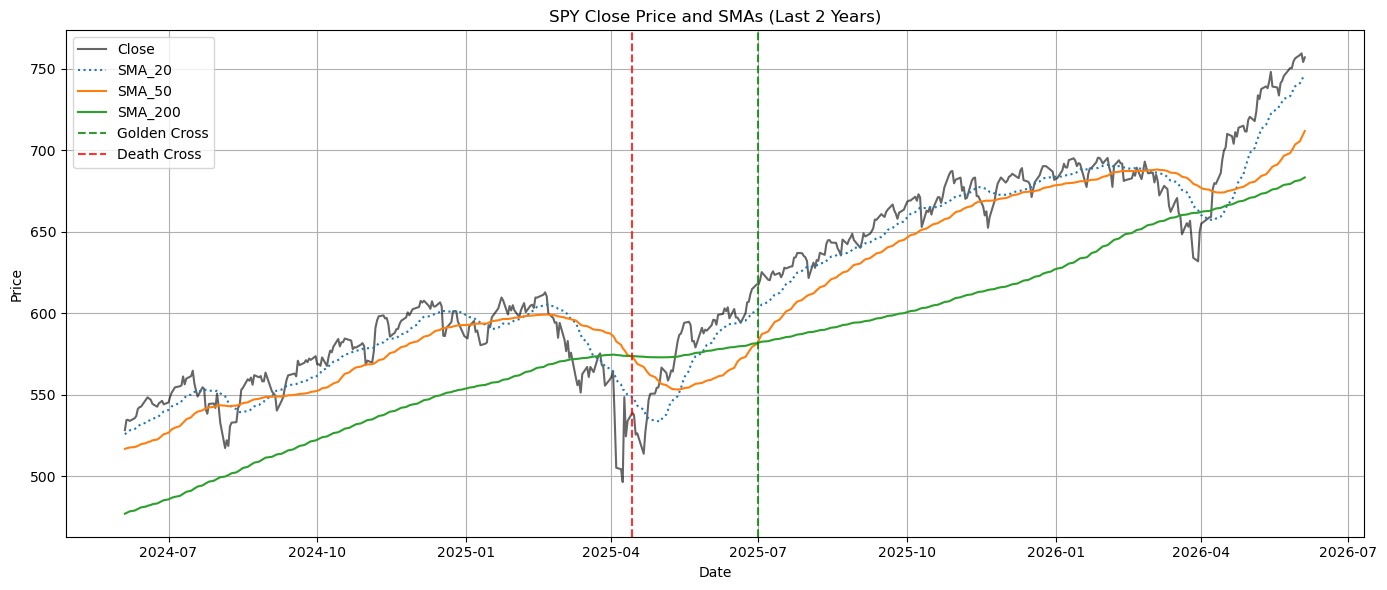

In [6]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

# recent = df.last('2Y').copy()  # Last 2 years of data
recent = df.loc[df.index.max() - pd.DateOffset(years=2):].copy()  # Last 2 years of data

# Excellent logic for finding the exact crossover dates
cross  = np.sign(recent['sma_50'] - recent['sma_200'])
golden = (cross > 0) & (cross.shift(1) <= 0)  # Golden Cross: sma_50 crosses above sma_200
death  = (cross < 0) & (cross.shift(1) >= 0)   # Death Cross: sma_50 crosses below sma_200

# Plot Graph
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the main price and moving averages
ax.plot(recent.index, recent['close'], label='Close', color='black', alpha=0.6)
ax.plot(recent.index, recent['sma_20'], label='SMA_20', linestyle=':')
ax.plot(recent.index, recent['sma_50'], label='SMA_50')
ax.plot(recent.index, recent['sma_200'], label='SMA_200')

# Iterate through the dates where 'golden' is True and draw a green vertical line
for date in recent.index[golden]:
    ax.axvline(x=date, color='green', linestyle='--', alpha=0.8, 
               label='Golden Cross' if date == recent.index[golden][0] else "")

# Iterate through the dates where 'death' is True and draw a red vertical line
for date in recent.index[death]:
    ax.axvline(x=date, color='red', linestyle='--', alpha=0.8, 
               label='Death Cross' if date == recent.index[death][0] else "")

ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
ax.set_title(f'{symbol} Close Price and SMAs (Last 2 Years)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [7]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20

df['ema_12']       = df['close'].ewm(span=12, adjust=False).mean()
df['ema_20']       = df['close'].ewm(span=20, adjust=False).mean()
df['ema_26']       = df['close'].ewm(span=26, adjust=False).mean()
df['ema_ratio_20'] = df['ema_12'] / df['ema_20']

C:\Users\sanja\AppData\Local\Temp\ipykernel_10832\1890322461.py:3: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last('365D')  # Last 365 days of data


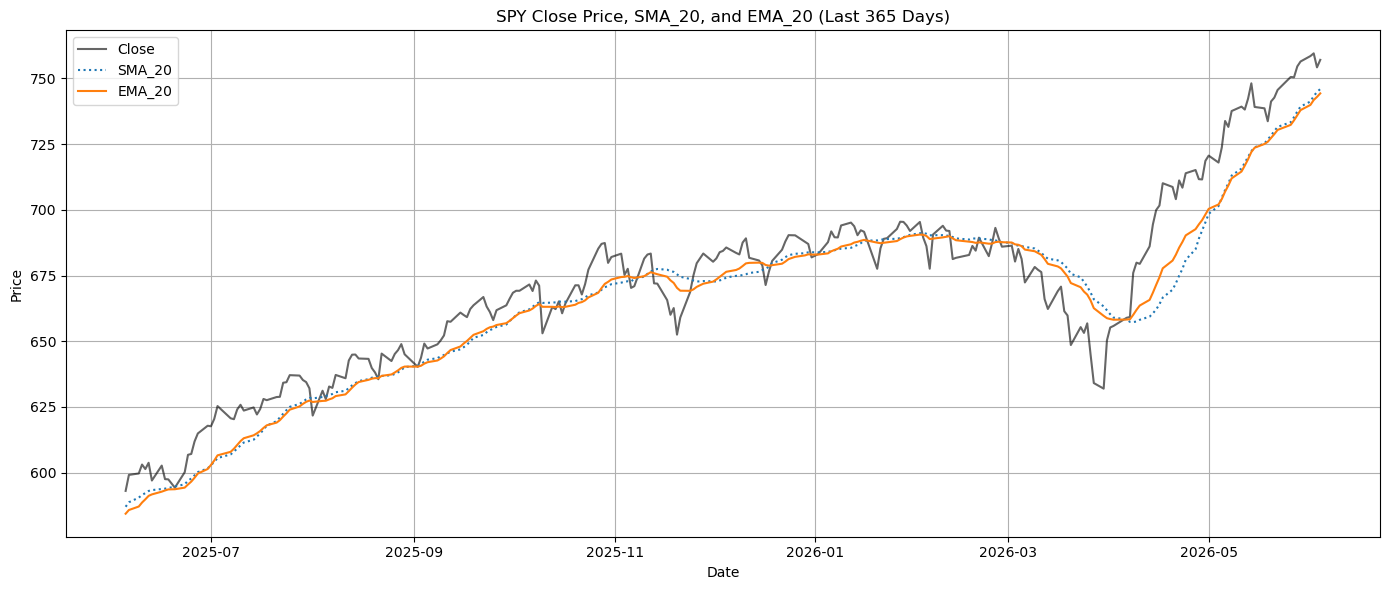

In [8]:
# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA
recent = df.last('365D')  # Last 365 days of data
plt.figure(figsize=(14, 6))
plt.plot(recent.index, recent['close'], label='Close', color='black', alpha=0.6)
plt.plot(recent.index, recent['sma_20'], label='SMA_20', linestyle=':')
plt.plot(recent.index, recent['ema_20'], label='EMA_20')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'{symbol} Close Price, SMA_20, and EMA_20 (Last 365 Days)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [9]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)

delta    = df['close'].diff()
gain     = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss     = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
avg_gain = gain.fillna(gain.iloc[0])
avg_loss = loss.fillna(loss.iloc[0])
rs       = avg_gain / avg_loss
df['rsi_14'] = 100 - (100 / (1 + rs))

C:\Users\sanja\AppData\Local\Temp\ipykernel_10832\2755534578.py:3: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last('365D')  # Last 365 days of data


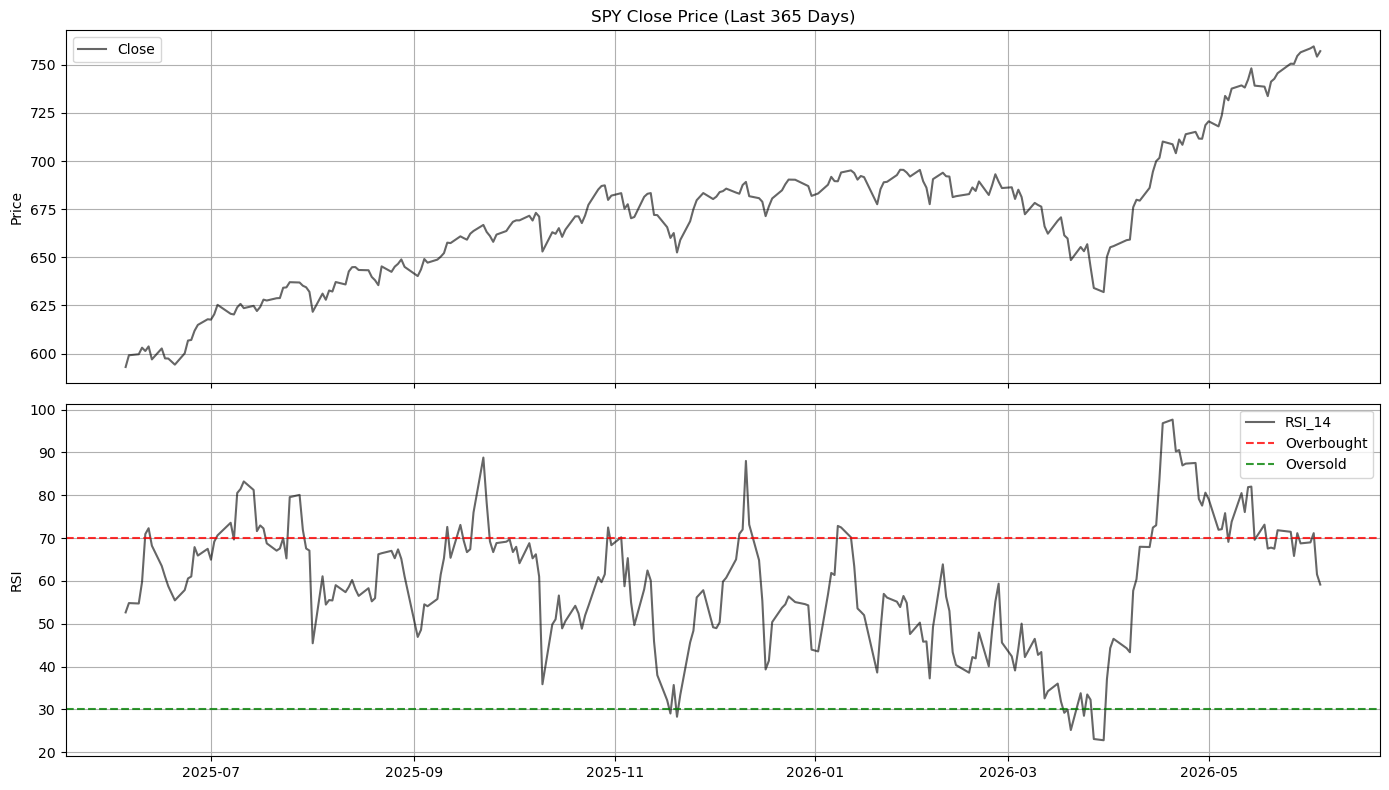

In [10]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green
recent = df.last('365D')  # Last 365 days of data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(recent.index, recent['close'], label='Close', color='black', alpha=0.6)
ax1.set_title(f'{symbol} Close Price (Last 365 Days)')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True)  # Turn on grid for better readability

ax2.plot(recent.index, recent['rsi_14'], label='RSI_14', color='black', alpha=0.6)
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.8, label='Overbought')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.8, label='Oversold')
ax2.set_ylabel('RSI')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [11]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

df['macd']        = df['ema_12'] - df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean() 
df['macd_hist']   = df['macd'] - df['macd_signal']

C:\Users\sanja\AppData\Local\Temp\ipykernel_34284\1028814512.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last('365D')  # Last 365 days of data


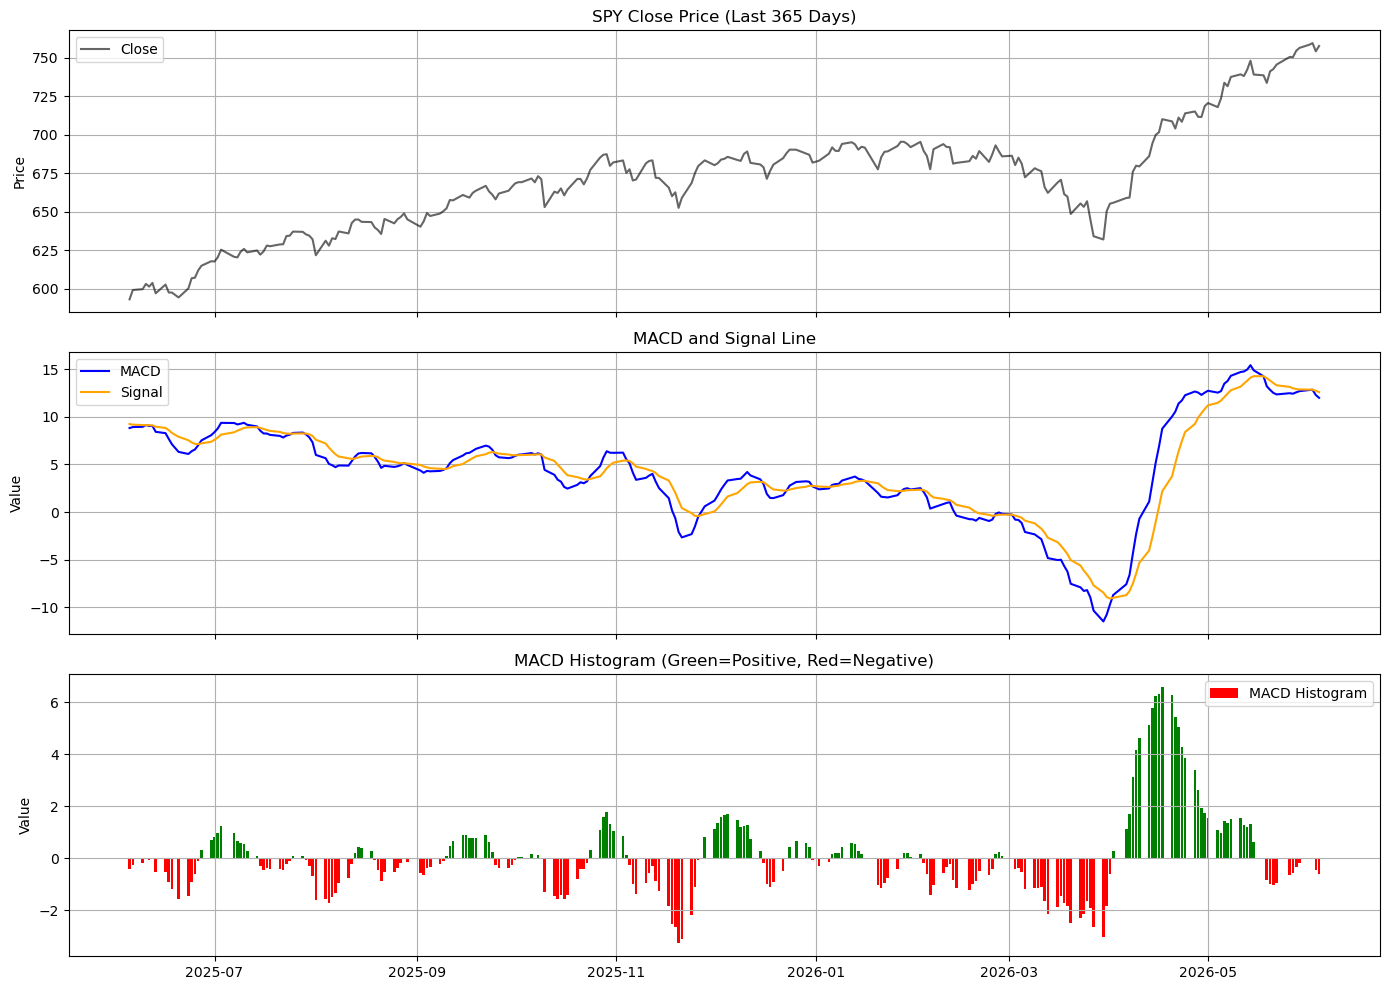

In [15]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign
recent = df.last('365D')  # Last 365 days of data
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
ax1.plot(recent.index, recent['close'], label='Close', color='black', alpha=0.6)
ax1.set_title(f'{symbol} Close Price (Last 365 Days)')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True)
ax2.plot(recent.index, recent['macd'], label='MACD', color='blue')
ax2.plot(recent.index, recent['macd_signal'], label='Signal', color='orange')
ax2.set_title('MACD and Signal Line')
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True)
# For the histogram, we can use bar plot with color based on sign
hist_colors = ['green' if val >= 0 else 'red' for val in recent['macd_hist']]
ax3.bar(recent.index, recent['macd_hist'], color=hist_colors, label='MACD Histogram')
ax3.set_title('MACD Histogram (Green=Positive, Red=Negative)')
ax3.set_ylabel('Value')
ax3.legend()
ax3.grid(True)
plt.tight_layout()
plt.show()

## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [16]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

rolling_std    = df['close'].rolling(window=20).std()
df['bb_upper'] = df['close'].rolling(window=20).mean() + (rolling_std * 2)
df['bb_lower'] = df['close'].rolling(window=20).mean() - (rolling_std * 2)
df['bb_width'] = df['bb_upper'] - df['bb_lower']
df['bb_pct_b'] = (df['close'] - df['bb_lower']) / df['bb_width']  # clip to [0, 1] optional but useful

## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [17]:
# TODO 6 — Compute roc_5 and roc_10

df['roc_5']  = df['close'].pct_change(periods=5) * 100
df['roc_10'] = df['close'].pct_change(periods=10) * 100

## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [18]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)

prev_close = df['close'].shift(1)
true_range = df['high'] - df['low']
true_range = true_range.combine(prev_close.sub(df['close'].shift(1)).abs(), max)
df['atr_14']    = true_range.ewm(com=13, adjust=False).mean()
df['atr_ratio'] = df['close'] / df['atr_14']

## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [19]:
# TODO 8.1 — Compute stoch_k and stoch_d

lowest_low   = df['low'].rolling(window=14).min()
highest_high = df['high'].rolling(window=14).max()
df['stoch_k'] = (df['close'] - lowest_low) / (highest_high - lowest_low) * 100
df['stoch_d'] = df['stoch_k'].rolling(window=3).mean()

C:\Users\sanja\AppData\Local\Temp\ipykernel_34284\2358756701.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last('365D')  # Last 365 days of data


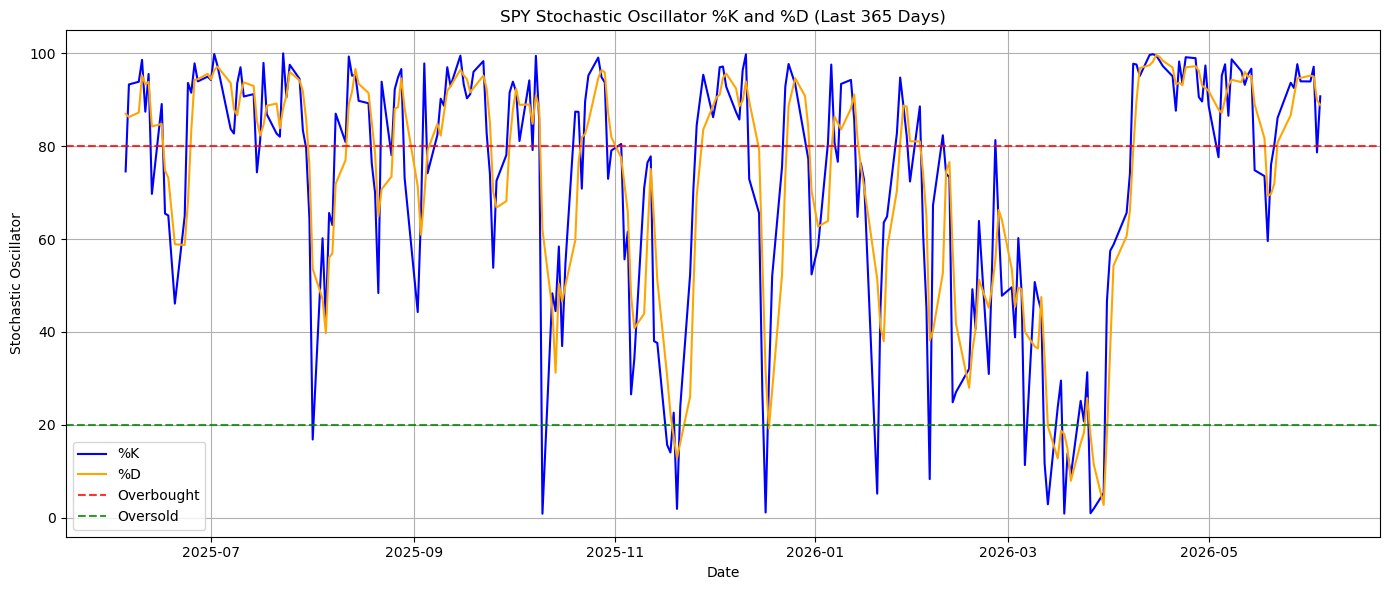

In [21]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# When %K crosses above %D from below the oversold zone → classic buy signal

recent = df.last('365D')  # Last 365 days of data
plt.figure(figsize=(14, 6))
plt.plot(recent.index, recent['stoch_k'], label='%K', color='blue')
plt.plot(recent.index, recent['stoch_d'], label='%D', color='orange')
plt.axhline(y=80, color='red', linestyle='--', alpha=0.8, label='Overbought')
plt.axhline(y=20, color='green', linestyle='--', alpha=0.8, label='Oversold')
plt.xlabel('Date')
plt.ylabel('Stochastic Oscillator')
plt.title(f'{symbol} Stochastic Oscillator %K and %D (Last 365 Days)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [22]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

direction       = np.sign(df['close'].diff())
df['obv']       = direction.cumsum()
df['obv_change']= df['obv'].diff()

## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [23]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

typical_price   = (df['high'] + df['low'] + df['close']) / 3
tp_vol          = typical_price * df['volume']
df['vwap']       = tp_vol.rolling(window=20).sum() / df['volume'].rolling(window=20).sum()
df['vwap_ratio'] = df['close'] / df['vwap']

## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [ ]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio',
]
# df.head()
# print(close)

date
2015-01-02    205.429993
2015-01-05    201.720001
2015-01-06    199.820007
2015-01-07    202.309998
2015-01-08    205.899994
                 ...    
2026-05-29    756.479980
2026-06-01    758.539978
2026-06-02    759.570007
2026-06-03    754.239990
2026-06-04    757.729980
Name: close, Length: 2872, dtype: float64


In [39]:
# TODO 11.1 — Add target columns, clean, and save
# 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
# 'target_direction' = 1 if future_return > 0, else 0
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns

df['future_return']    = close.shift(-1) / close - 1
df['target_direction'] = (df['future_return'] > 0).astype(int)

required = ['future_return', 'target_direction'] + [col for col in df.columns if col.startswith(('rsi', 'stoch', 'obv', 'vwap'))]
df       = df[required]
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()

out_path = PROCESSED_DIR / f'{safe_symbol(symbol)}_features.csv'
df_clean.to_csv(out_path, index=False)
print(f"Output saved to: {out_path}")
print(f"Shape: {df_clean.shape}")
df_clean[required].describe().round(4)

Output saved to: data\processed\SPY_features.csv
Shape: (2852, 9)


,future_return,target_direction,rsi_14,stoch_k,stoch_d,obv,obv_change,vwap,vwap_ratio
count,2852.0000,2852.0000,2852.0,2852.0,2852.0,2852.0000,2852.0000,2852.0000,2852.0000
mean,0.0005,0.5470,0.0,0.0,0.0,117.6147,0.0954,371.4900,1.0069
std,0.0112,0.4979,0.0,0.0,0.0,83.3666,0.9946,142.3126,0.0241
min,-0.1094,0.0000,0.0,0.0,0.0,-12.0000,-1.0000,187.9745,0.8185
25%,-0.0037,0.0000,0.0,0.0,0.0,44.0000,-1.0000,253.9548,0.9961
50%,0.0006,1.0000,0.0,0.0,0.0,139.5000,1.0000,339.2528,1.0095
75%,0.0059,1.0000,0.0,0.0,0.0,176.0000,1.0000,447.7652,1.0199
max,0.1050,1.0000,0.0,0.0,0.0,271.0000,1.0000,743.7042,1.1316


In [41]:
# TODO 11.2 (Challenge) — Run the full pipeline for ALL downloaded symbols
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct

summary = []
for csv_path in RAW_DIR.glob('*.csv'):
    sym = csv_path.stem  # Get symbol from filename
    try:
        raw       = pd.read_csv(csv_path)  # Load raw data
        # ... compute all indicators on raw ...
        processed = df # Clean and prepare processed DataFrame
        # ... save to PROCESSED_DIR ...
        summary.append({
            'symbol': sym,
            'rows_raw': len(raw),
            'rows_processed': len(processed),
            'drop_pct': (1 - len(processed) / len(raw)) * 100
        })
    except Exception as e:
        summary.append({'symbol': sym, 'error': str(e)})

pd.DataFrame(summary)


,symbol,rows_raw,rows_processed,drop_pct
0,AAPL,2872,2872,0.000000
1,BSESN,2809,2872,-2.242791
2,BTC_USD,4173,2872,31.176612
3,ETH_USD,3130,2872,8.242812
4,EURUSD_X,2973,2872,3.397242
5,GSPC,2872,2872,0.000000
6,INFY_NS,2821,2872,-1.807870
7,IXIC,2872,2872,0.000000
8,JPY_X,2973,2872,3.397242
9,MSFT,2872,2872,0.000000


---
